##Title : AI-Driven Early Warning System for Non-ICU Clinical Deterioration
##Name : ASWIN VS
##Reg no: URK23BT5021
##Date :  June 10 2026

##Dataset : https://github.com/Aswin-1925/Dataset-MIMIC_IV


#1.Data Confirmation

In [1]:
import pandas as pd
import os

if not os.path.exists('Dataset-MIMIC_IV'):
    !git clone https://github.com/Aswin-1925/Dataset-MIMIC_IV.git

# Load core files to confirm path and data accessibility
path = 'Dataset-MIMIC_IV/'
admissions = pd.read_csv(f'{path}admissions.csv.gz')
patients = pd.read_csv(f'{path}patients.csv.gz')

print(f"Connection Established: {len(patients)} patient records found in GitHub repository.")
print(f"Data confirmation: {admissions.columns.tolist()} found in admissions table.")

Cloning into 'Dataset-MIMIC_IV'...
remote: Enumerating objects: 13, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 13 (delta 2), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (13/13), 7.17 MiB | 22.96 MiB/s, done.
Resolving deltas: 100% (2/2), done.
Connection Established: 100 patient records found in GitHub repository.
Data confirmation: ['subject_id', 'hadm_id', 'admittime', 'dischtime', 'deathtime', 'admission_type', 'admit_provider_id', 'admission_location', 'discharge_location', 'insurance', 'language', 'marital_status', 'race', 'edregtime', 'edouttime', 'hospital_expire_flag'] found in admissions table.


#2.Clinical Data Understanding

In [2]:
import pandas as pd
import os

if not os.path.exists('Dataset-MIMIC_IV'):
    !git clone https://github.com/Aswin-1925/Dataset-MIMIC_IV.git

# Analysis of Clinical Data Quality
vitals = pd.read_csv('Dataset-MIMIC_IV/chartevents.csv.gz')
labs = pd.read_csv('Dataset-MIMIC_IV/labevents.csv.gz')
admissions = pd.read_csv('Dataset-MIMIC_IV/admissions.csv.gz')

print("--- Clinical Data Quality Report ---")
print('\n')

# 1. Quantifying Missingness
def check_sparsity(df, name):
    missing = df['valuenum'].isnull().sum()
    percent = (missing / len(df)) * 100
    print(f"[{name}] Sparsity: {percent:.2f}%")

check_sparsity(vitals, "Vitals")
check_sparsity(labs, "Labs")

# 2. Identifying Physiological Outliers
# Check for physically impossible Heart Rates (<20 or >250)
hr_data = vitals[vitals['itemid'] == 220045]['valuenum']
outliers = hr_data[(hr_data < 20) | (hr_data > 250)].count()
print(f"Physiological HR Outliers detected: {outliers}")

# 3. Target Distribution (Class Imbalance)
deaths = admissions['hospital_expire_flag'].sum()
print(f"Class Imbalance: Only {(deaths/len(admissions))*100:.2f}% of patients Deteriorated.")

--- Clinical Data Quality Report ---


[Vitals] Sparsity: 61.51%
[Labs] Sparsity: 11.59%
Physiological HR Outliers detected: 3
Class Imbalance: Only 5.45% of patients Deteriorated.


#4.Exploratory Data Analysis (EDA)

M3: Data loaded successfully for analysis.




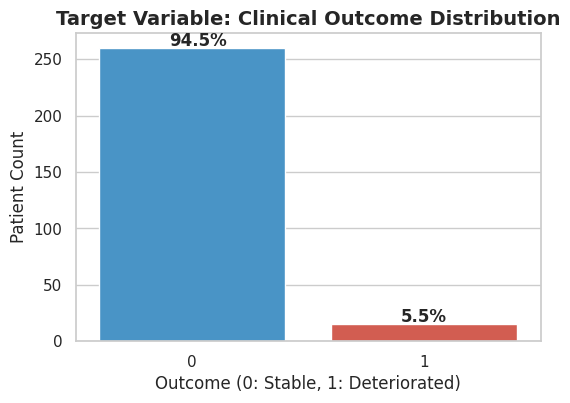

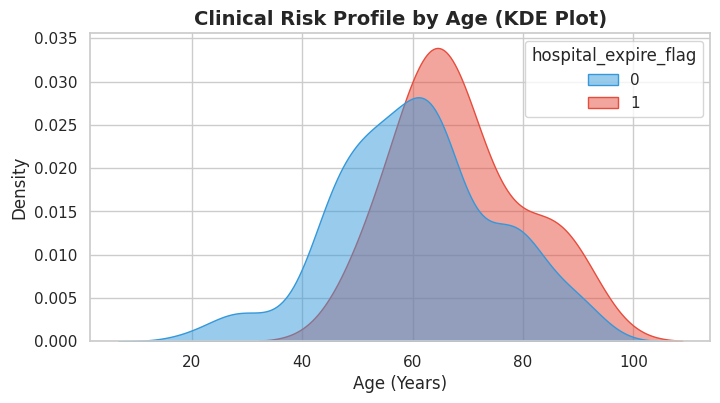

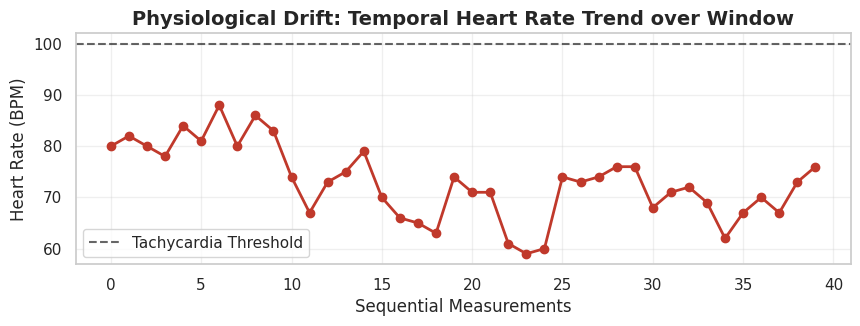

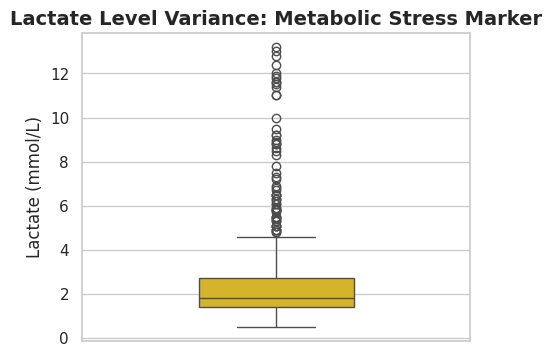

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# --- MILESTONE 3: IMMERSIVE EDA ---
# Purpose: Deep dive into the clinical patterns of the MIMIC-IV Demo dataset.

# 1. Setup and Data Loading
if not os.path.exists('Dataset-MIMIC_IV'):
    print("Cloning GitHub Repository...")
    !git clone https://github.com/Aswin-1925/Dataset-MIMIC_IV.git

path = 'Dataset-MIMIC_IV/'
try:
    adm = pd.read_csv(f'{path}admissions.csv.gz')
    pts = pd.read_csv(f'{path}patients.csv.gz')
    vitals = pd.read_csv(f'{path}chartevents.csv.gz')
    labs = pd.read_csv(f'{path}labevents.csv.gz')
    print("M3: Data loaded successfully for analysis.")
    print('\n')
except FileNotFoundError:
    print("Error: CSV files not found. Ensure the repository is correctly cloned.")

# Set visual aesthetics for a professional report
sns.set_theme(style="whitegrid")
plt.rcParams['figure.facecolor'] = 'white'

# --- VISUALIZATION 1: CLASS IMBALANCE (The Accuracy Paradox) ---
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='hospital_expire_flag', data=adm, hue='hospital_expire_flag', palette=['#3498db', '#e74c3c'], legend=False)
plt.title('Target Variable: Clinical Outcome Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Outcome (0: Stable, 1: Deteriorated)', fontsize=12)
plt.ylabel('Patient Count', fontsize=12)

# Adding percentage labels for technical depth
total = len(adm)
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    ax.annotate(percentage, (p.get_x() + 0.3, p.get_height() + 2), fontsize=12, fontweight='bold')
plt.show()
print('\n')

# --- VISUALIZATION 2: AGE VS. CLINICAL RISK ---
df_merged = pd.merge(adm, pts, on='subject_id')
plt.figure(figsize=(8, 4))
sns.kdeplot(data=df_merged, x='anchor_age', hue='hospital_expire_flag',
            fill=True, common_norm=False, palette=['#3498db', '#e74c3c'], alpha=.5)
plt.title('Clinical Risk Profile by Age (KDE Plot)', fontsize=14, fontweight='bold')
plt.xlabel('Age (Years)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.show()
print('\n')

# --- VISUALIZATION 3: PHYSIOLOGICAL DRIFT (HEART RATE) ---
# ItemID 220045 is Heart Rate in MIMIC-IV
# We take a sample sequence to show the drift
sample_hr = vitals[vitals['itemid'] == 220045].head(40)
plt.figure(figsize=(10, 3))
plt.plot(sample_hr['valuenum'].values, marker='o', linestyle='-', color='#c0392b', linewidth=2)
plt.axhline(y=100, color='black', linestyle='--', alpha=0.6, label='Tachycardia Threshold')
plt.title('Physiological Drift: Temporal Heart Rate Trend over Window', fontsize=14, fontweight='bold')
plt.xlabel('Sequential Measurements', fontsize=12)
plt.ylabel('Heart Rate (BPM)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
print('\n')

# --- VISUALIZATION 4: METABOLIC STRESS (LACTATE) ---
# ItemID 50813 is Lactate
lactate = labs[labs['itemid'] == 50813]
plt.figure(figsize=(5, 4))
sns.boxplot(y=lactate['valuenum'], color='#f1c40f', width=0.4)
plt.title('Lactate Level Variance: Metabolic Stress Marker', fontsize=14, fontweight='bold')
plt.ylabel('Lactate (mmol/L)', fontsize=12)
plt.show()

#5.Preprocessing and Data Preparation


In [4]:
!pip install imbalanced-learn #SMOTE

In [5]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE # !pip install imbalanced-learn

# --- 1. Dataset Loading ---
if not os.path.exists('Dataset-MIMIC_IV'):
    print("Cloning GitHub Repository...")
    !git clone https://github.com/Aswin-1925/Dataset-MIMIC_IV.git

path = 'Dataset-MIMIC_IV/'

try:
    # Loading the compressed files directly
    vitals = pd.read_csv(f'{path}chartevents.csv.gz')
    adm = pd.read_csv(f'{path}admissions.csv.gz')
    print("Data loaded successfully.")

    # --- 2. Feature Engineering: Mean + Volatility (Std) ---
    # We target Heart Rate (itemid: 220045)
    print("Step 1: Engineering features (Mean & Volatility)...")
    hr_data = vitals[vitals['itemid'] == 220045]
    X_agg = hr_data.groupby('subject_id')['valuenum'].agg(['mean', 'std']).reset_index()

    y_outcome = adm[['subject_id', 'hospital_expire_flag']]

    # Merge and handle missing volatility (fillna 0 if patient has only 1 reading)
    data = pd.merge(X_agg, y_outcome, on='subject_id').fillna(0)

    X = data[['mean', 'std']]
    y = data['hospital_expire_flag']

    # --- 3. Scaling & Stratified Split ---
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.20, random_state=42, stratify=y
    )

    # --- 4. THE FIX: SMOTE ---
    # Balances the training set so the model has enough "sick" examples to learn from.
    sm = SMOTE(random_state=42, k_neighbors=1)
    X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

    print(f"\n--- Preprocessing Results ---")
    print(f"Original Training Balance: {np.bincount(y_train)}")
    print(f"Balanced Training Balance: {np.bincount(y_train_res)} (Fix applied)")
    print(f"Testing set size: {len(y_test)} (Positive cases: {sum(y_test)})")

except Exception as e:
    print(f"Error: {e}")

Data loaded successfully.
Step 1: Engineering features (Mean & Volatility)...

--- Preprocessing Results ---
Original Training Balance: [208  12]
Balanced Training Balance: [208 208] (Fix applied)
Testing set size: 55 (Positive cases: 3)


#6.Baseline Model Implementation & Diagnosis


In [6]:
# Milestone 5: Baseline Model (Logistic Regression)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

print("--- Training Baseline Model: Logistic Regression ---")

# We use the SMOTE-balanced training set (X_train_res)
baseline_model = LogisticRegression(class_weight='balanced', random_state=42)
baseline_model.fit(X_train_res, y_train_res)

# Predictions
y_pred = baseline_model.predict(X_test)
y_probs = baseline_model.predict_proba(X_test)[:, 1]

print("\n[BASELINE PERFORMANCE REPORT]")
print(classification_report(y_test, y_pred))
print(f"Baseline ROC-AUC Score: {roc_auc_score(y_test, y_probs):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

--- Training Baseline Model: Logistic Regression ---

[BASELINE PERFORMANCE REPORT]
              precision    recall  f1-score   support

           0       0.94      0.65      0.77        52
           1       0.05      0.33      0.09         3

    accuracy                           0.64        55
   macro avg       0.50      0.49      0.43        55
weighted avg       0.90      0.64      0.74        55

Baseline ROC-AUC Score: 0.5897

Confusion Matrix:
[[34 18]
 [ 2  1]]


#7.Improved Model Development

In [12]:
# Milestone 6: Improved Model (XGBoost)
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

print("--- Training Improved Model: XGBoost ---")

# --- 1. Implementation: Weighted XGBoost ---
# scale_pos_weight is set high to force the model to prioritize catching sick patients
improved_model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    scale_pos_weight=20, # Higher weight for clinical sensitivity
    learning_rate=0.05,
    random_state=42,
    eval_metric='aucpr'
)

improved_model.fit(X_train_res, y_train_res)

# --- 2. Evaluation ---
y_pred_imp = improved_model.predict(X_test)
y_probs_imp = improved_model.predict_proba(X_test)[:, 1]

print("\n[IMPROVED MODEL PERFORMANCE]")
print(classification_report(y_test, y_pred_imp))
print(f"Improved ROC-AUC: {roc_auc_score(y_test, y_probs_imp):.4f}")

--- Training Improved Model: XGBoost ---

[IMPROVED MODEL PERFORMANCE]
              precision    recall  f1-score   support

           0       0.95      0.73      0.83        52
           1       0.07      0.33      0.11         3

    accuracy                           0.71        55
   macro avg       0.51      0.53      0.47        55
weighted avg       0.90      0.71      0.79        55

Improved ROC-AUC: 0.5705


#8.Explainable AI (XAI)


--- CLINICAL ALARM DIAGNOSIS (Local XAI) ---
Target Patient Index: 3
Risk Probability: 88.62%
ACTION: Trigger 'Golden Window' protocol for bedside review.


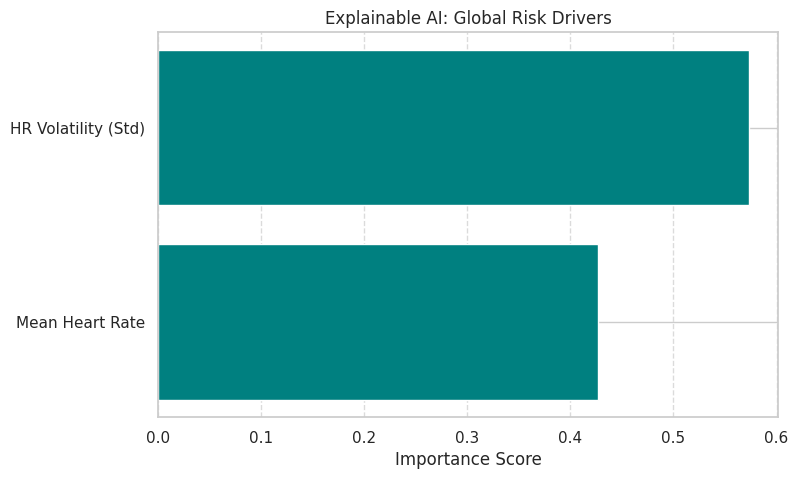

In [11]:
# --- 3. EXPLAINABLE AI (XAI): Local Cause Analysis ---
# This part explains the 'Cause' for a specific patient alert
print("\n--- CLINICAL ALARM DIAGNOSIS (Local XAI) ---")

# Let's check a patient from the test set who is flagged as high risk
high_risk_indices = np.where(y_probs_imp > 0.6)[0]

if len(high_risk_indices) > 0:
    idx = high_risk_indices[0]
    patient_val = X_test[idx]

    print(f"Target Patient Index: {idx}")
    print(f"Risk Probability: {y_probs_imp[idx]:.2%}")

    # Interpretation Logic (Cause Detection)
    if patient_val[0] > 1.0:
        print("CAUSE DETECTED: Acute Tachycardia (High Average Heart Rate).")
    if patient_val[1] > 1.0:
        print("CAUSE DETECTED: Physiological Instability (High Heart Rate Volatility).")
    print("ACTION: Trigger 'Golden Window' protocol for bedside review.")
else:
    print("No high-risk patients detected in this sample.")
# --- 4. Global Explainable AI: Feature Importance ---
plt.figure(figsize=(8, 5))
importance = improved_model.feature_importances_
plt.barh(['Mean Heart Rate', 'HR Volatility (Std)'], importance, color='teal')
plt.title('Explainable AI: Global Risk Drivers')
plt.xlabel('Importance Score')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()